# 2.5.3 Transformer の学習
Transformerで機械翻訳タスクを学習させる。  

- エンコーダー
  - 入力文章を埋め込みベクトルに変換する役割
- デコーダー
  - エンコーダーから渡された埋め込みベクトルと、デコーダー自身の出力をもとに、次の単語を予測する役割

In [21]:
import torch
from torch import Tensor

## コーパスの用意
学習に用いるデータセット(田中コーパス)を取得。  
田中コーパス: 日英の文章コーパスを前処理(小文字化やトークン化)したデータセット

In [22]:
from pathlib import Path

data_dir = Path("small_parallel_enja")
if not data_dir.exists():
    !git clone https://github.com/odashi/small_parallel_enja.git {data_dir}

train_ja = data_dir / "train.ja.000" # 日本語の文章コーパスを1万件取得
train_en = data_dir / "train.en.000" # 英語の文章コーパスを1万件取得

データセットから日本語と英語の文章をそれぞれ取得。  
行毎に`<bos>`および`<eos>` Tokenを追加、および空白で区切ったリストに変換する。

In [23]:
from typing import Iterator

# iter_corpusはジェネレータ関数として、呼ばれるたびに1文ずつ順番にトークンリストを返す
def iter_corpus(
    path: Path,
    bos: str | None = "<bos>",
    eos: str | None = "<eos>",
) -> Iterator[list[str]]:
    with path.open("r") as f:
        for line in f:
            if bos: # 先頭に<bos>トークンを追加
                line = bos + " " + line
            if eos: # 末尾に<eos>トークンを追加
                line = line + " " + eos
            yield line.split() # 1行分の文章を単語ごとのリストにして1件ずつ返す(split()で空白区切りの単語リストになる)


# iter_corpus()で返ってきた各文章のトークンリストをリストに格納
train_tokens_ja = [tokens for tokens in iter_corpus(train_ja)]
train_tokens_en = [tokens for tokens in iter_corpus(train_en)]

In [24]:
print(train_tokens_ja[:3]) # 日本語の文章コーパスの最初の3件を表示
print(train_tokens_en[:3]) # 英語の文章コーパスの最初の3件を表示

[['<bos>', '誰', 'が', '一番', 'に', '着', 'く', 'か', '私', 'に', 'は', '分か', 'り', 'ま', 'せ', 'ん', '。', '<eos>'], ['<bos>', '多く', 'の', '動物', 'が', '人間', 'に', 'よ', 'っ', 'て', '滅ぼ', 'さ', 'れ', 'た', '。', '<eos>'], ['<bos>', '私', 'は', 'テニス', '部員', 'で', 'す', '。', '<eos>']]
[['<bos>', 'i', 'can', "'t", 'tell', 'who', 'will', 'arrive', 'first', '.', '<eos>'], ['<bos>', 'many', 'animals', 'have', 'been', 'destroyed', 'by', 'men', '.', '<eos>'], ['<bos>', 'i', "'m", 'in', 'the', 'tennis', 'club', '.', '<eos>']]


## ボキャブラリーの作成
重複なく単語のリストを持つことで各単語に一意のIDを割り当てることができる。

ボキャブラリーを作成する関数を定義

In [25]:
from collections import Counter

def build_vocab_from_iterator(
    iterator: Iterator[list[str]], specials: list[str]
) -> dict[str, int]:
    """語彙構築"""

    # 単語の出現回数を数える
    # 出現回数と単語を紐づけた辞書を作成
    counter = Counter()  
    for tokens in iterator:
        counter.update(tokens)

    # vocabの作成
    # 出現頻度が多い単語順にtoken idを割り当てる

    # specials を先頭に配置
    vocab = {token: idx for idx, token in enumerate(specials)}
    idx = len(specials)

    # 出現回数の多い順に単語を並べ、vocabに追加していく
    for token, _ in counter.most_common():
        if token not in vocab:
            vocab[token] = idx
            idx += 1
    return vocab

コーパスからボキャブラリーを作成。

In [26]:
vocab_ja_dict = build_vocab_from_iterator(
    iterator=train_tokens_ja,
    specials=["<unk>", "<pad>", "<bos>", "<eos>"],
)

vocab_en_dict = build_vocab_from_iterator(
    iterator=train_tokens_en,
    specials=["<unk>", "<pad>", "<bos>", "<eos>"],
)

print(list(vocab_ja_dict.items())[:10])
print(list(vocab_en_dict.items())[:10])

[('<unk>', 0), ('<pad>', 1), ('<bos>', 2), ('<eos>', 3), ('。', 4), ('は', 5), ('い', 6), ('に', 7), ('た', 8), ('を', 9)]
[('<unk>', 0), ('<pad>', 1), ('<bos>', 2), ('<eos>', 3), ('.', 4), ('the', 5), ('i', 6), ('to', 7), ('you', 8), ('is', 9)]


単なる辞書だとtoken->idの変換しかできないため、`Vocab`クラスを定義することで逆引きや未知の単語に対してデフォルトtokenを返すことができるようにする。

In [ ]:
class Vocab:
    """語彙クラスの実装"""

    def __init__(self, token_to_idx: dict, default_index: int = 0):
        self.token_to_idx = token_to_idx
        self.idx_to_token = {idx: token for token, idx in token_to_idx.items()}
        self.default_index = default_index

    # token_idを返す(Vocab[token] -> token_id)
    # tokenに対応するtoken_idが存在しなければdefault_indexを返す
    def __getitem__(self, token):
        return self.token_to_idx.get(token, self.default_index) 

    def __len__(self): # ボキャブラリーのサイズを返す
        return len(self.token_to_idx)

    # デフォルトtoken idを設定する
    def set_default_index(self, index): 
        self.default_index = index

    # index to string のリストを返す
    def get_itos(self):  
        return [self.idx_to_token[i] for i in range(len(self.idx_to_token))]

In [28]:
vocab_ja = Vocab(vocab_ja_dict)
vocab_ja.set_default_index(vocab_ja["<unk>"]) # <unk>トークンのtoken idをデフォルトindexに設定する
vocab_en = Vocab(vocab_en_dict)
vocab_en.set_default_index(vocab_en["<unk>"]) # <unk>トークンのtoken idをデフォルトindexに設定する

Vocabクラスを使ったtoken idの取得例

In [ ]:
print("<unk>:", vocab_ja["<unk>"]) # <unk>トークンのtoken idを表示

# tokenに対応するtoken idを表示
tokens = ["<bos>", "吾輩", "は", "猫", "で", "ある", "<eos>"]
for token in tokens:
    print(token, ":", vocab_ja[token], "\n", end=" ")

<unk>: 0
<bos> : 2 
 吾輩 : 0 
 は : 5 
 猫 : 428 
 で : 12 
 ある : 669 
 <eos> : 3 
 

## DataLoaderの作成
トークンリスト(単語)をトークンIDのテンソルに変換してパディングを追加する関数を定義。  


In [43]:
from torch.nn.utils.rnn import pad_sequence

# トークンリストをトークンIDテンソルに変換してパディングを追加
def tokens_to_tensor(
    tokens_list: list[list[str]], vocab: Vocab, padding_value: int
) -> Tensor:
    """"
      tokens_list: 複数文のトークン列
      vocab: ボキャブラリー
      padding_value: パディングに使用するtoken id
    """

    # トークンリスト(複数文)から1つずつ取り出して、各文章毎にtoken idのテンソルを作成する
    #  この時点では各要素のテルソンは長さが違う
    sequences = [
        torch.tensor([vocab[token] for token in tokens], dtype=torch.long)
        for tokens in tokens_list
    ]
    # <pad>トークンを追加してテルソンの長さを揃え、バッチテルソンに変換
    return pad_sequence(sequences, batch_first=True, padding_value=padding_value)

確認

In [44]:
# tokens_to_tensorの確認
tokens = [["道路", "を", "横切", "る"],
          ["弁当", "を", "食べ", "ま", "す"],
          ["曇り", "の", "日", "が", "好き", "で", "す"]]

tensor_tokens = tokens_to_tensor(tokens, vocab_ja, vocab_ja["<pad>"])
print("tensor_tokens: \n", tensor_tokens)

tensor_tokens: 
 tensor([[ 799,    9, 1030,   18,    1,    1,    1],
        [1273,    9,  153,   21,   19,    1,    1],
        [1560,   10,   75,   14,   85,   12,   19]])


DataLoader作成時に前処理を行う関数を定義。  
日本語と英語のトークンリストをペアに持つバッチを受け取って、token idテルソンへの変換およびパディング追加を行う。

In [45]:
# DataLoader作成時に前処理を行う関数を定義
#  batchには[(日本語文1, 英語分1), (日本語文2, 英語文2), ...]の形式で複数文が格納されている
#  batchから日本語文と英語文のトークンリストをそれぞれ取り出して、tokens_to_tensor()でパディング済みテンソルに変換して返す
def collate_fn(batch: list) -> tuple[Tensor, Tensor]:
    src_texts, tgt_texts = [], []
    for s, t in batch:
        src_texts.append(s) # 日本語のトークンリスト
        tgt_texts.append(t) # 英語のトークンリスト

    src_tensor = tokens_to_tensor(src_texts, vocab_ja, vocab_ja["<pad>"])
    tgt_tensor = tokens_to_tensor(tgt_texts, vocab_en, vocab_en["<pad>"])

    return src_tensor, tgt_tensor

確認

In [46]:
# collate_fnの確認
batch = [(["道路", "を", "横切", "る"], ["i", "cross", "the", "road"]),
         (["弁当", "を", "食べ", "ま", "す"], ["i", "eat", "a", "lunch", "."]),
         (["曇り", "の", "日", "が", "好き", "で", "す"], ["i", "like", "cloudy", "days", "."])]
src_tensor, tgt_tensor = collate_fn(batch)
print("src_tensor: \n", src_tensor)
print("tgt_tensor: \n", tgt_tensor)

src_tensor: 
 tensor([[ 799,    9, 1030,   18,    1,    1,    1],
        [1273,    9,  153,   21,   19,    1,    1],
        [1560,   10,   75,   14,   85,   12,   19]])
tgt_tensor: 
 tensor([[   6, 1061,    5,  623,    1],
        [   6,  270,   11,  407,    4],
        [   6,   46,  904,  221,    4]])


DataLoaderの作成

In [32]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    list(zip(train_tokens_ja, train_tokens_en)),
    batch_size=64, # 16から変更
    shuffle=True,
    collate_fn=collate_fn,
)

In [33]:
# DataLoaderから最初のバッチを取得して内容を表示
batch = next(iter(train_loader))
src_tensor, tgt_tensor = batch
print("src_tensor shape: ", src_tensor.shape)  # torch.Size([16, sequence_length])
print("src_tensor[0]: \n", src_tensor[0])  # src_tensorの内容を表示
print("tgt_tensor shape: ", tgt_tensor.shape)  # torch.Size([16, sequence_length])
print("tgt_tensor[0]: \n", tgt_tensor[0])  # tgt_tensorの内容を表示

src_tensor shape:  torch.Size([64, 18])
src_tensor[0]: 
 tensor([  2, 123,  77, 964,  15,   7,  69,  20,  11,   6,  13,   6,   4,   3,
          1,   1,   1,   1])
tgt_tensor shape:  torch.Size([64, 15])
tgt_tensor[0]: 
 tensor([  2,   6,  16,  32, 275,  42, 274,   4,   3,   1,   1,   1,   1,   1,
          1])


## Transformerインスタンスの作成

In [ ]:
import torch

from llm_from_scratch.transformer.transformer import Transformer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device, "を使用")

embedding_dim = 512 # 埋め込みベクトルの次元数
n_blocks = 6 # 各ブロックの繰り返し数
n_heads = 8 # マルチヘッドアテンションのヘッド数
expansion_rate = 1 # FFNの隠れ層の次元数を埋め込みベクトルの次元数の何倍にするか

# 語彙数を取得
src_vocab_size = len(vocab_ja)
tgt_vocab_size = len(vocab_en)

# 最も長い文章の長さを取得
#  max(train_tokens_ja, key=lambda x: len(x))で、train_tokens_jaの中で最も長いトークンリストを取得
#  lambda x: len(x) で「各トークンリストの長さを比較基準にする」という意味
max_len_ja = len(max(train_tokens_ja, key=lambda x: len(x)))
max_len_en = len(max(train_tokens_en, key=lambda x: len(x)))
max_length = max(max_len_ja, max_len_en) # 日本語と英語の中で最も長い文章の長さを取得

# Transformerモデルのインスタンスを作成
model = Transformer(
    src_vocab_size,
    tgt_vocab_size,
    max_sequence_len=max_length,
    d_model=embedding_dim,
    n_blocks=n_blocks,
    n_heads=n_heads,
    d_k=embedding_dim,
    d_v=embedding_dim,
    d_ff=embedding_dim * expansion_rate,
).to(device)

cuda を使用


## 損失関数と最適化関数の定義

In [35]:
from torch import nn

# 損失関数の定義(<pad>トークンのtoken idを無視するように設定)
PAD_ID = vocab_ja["<pad>"]
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)  # クロスエントロピー

# 最適化関数の定義
lr = 0.0001  # 学習率
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

# 学習率スケジューラーの定義
#   学習率スケジューラーは、学習の進行に応じて学習率を調整するための仕組み
#   10エポックごとに学習率を0.95倍に減衰させるStepLRを使用
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 10.0, gamma=0.95)

## マスク関数の定義
バッチトークンに対してパディングマスクと後続マスクを作成する関数を定義。
- パディングマスク
  - `<pad>` Tokenに対応する位置のAttention重みを0にするためのマスク。
- 後続マスク
  - 特定のTokenの位置よりも後ろのtokenに対応する位置のAttention重みを0にするためのマスク。(デコーダのみ)

In [36]:
# パディングマスク
def create_padding_mask(pad_id: int, batch_tokens: Tensor):
    mask = batch_tokens == pad_id  # batch_tokens内の各トークンがpad_idであるかを判定し、True/Falseの行列を作成
    mask = mask.unsqueeze(1) # 次元を追加してマスクの形状を(batch_size, sequence_length)->(batch_size, 1, sequence_length)に変換
    return mask

# 後続マスク
def create_subsequent_mask(batch_tokens: Tensor):
    sequence_len = batch_tokens.size(1)
    mask = torch.triu(
        torch.full((sequence_len, sequence_len), 1), # 上三角行列を作成(上三角の要素を1、その他を0とする)
        diagonal=1,
    )
    mask = mask == 1  # 各要素の値が1であるかを判定し、True/Falseの行列を作成
    mask = mask.unsqueeze(0) # 次元を追加してマスクの形状を(sequence_length, sequence_length)->(1, sequence_length, sequence_length)に変換
    return mask

### 学習関数の定義

In [ ]:
def train(model: nn.Module, log_interval: int = 10) -> list[float]:
    model.train()
    loss_history = []
    for i, (src_texts, tgt_texts) in enumerate(train_loader):
        '''
         src_texts: 日本語のトークンIDテンソルバッチ
         tgt_texts: 英語のトークンIDテンソルバッチ
        '''

        # tgt_textsからデコーダーの入力と出力(教師データ)を作成
        tgt_input = tgt_texts[:, :-1] # 入力は最後の単語を除く(次の予測が存在しない<eos>トークンを除く)
        tgt_output = tgt_texts[:, 1:] # 出力は最初の単語を除く(予測対象ではない<bos>トークンを除く)

        # マスクの作成
        src_padding_mask = create_padding_mask(PAD_ID, src_texts) # パディングマスクを作成(エンコーダー)
        tgt_padding_mask = create_padding_mask(PAD_ID, tgt_input) # パディングマスクを作成(デコーダー)
        tgt_subsequent_mask = create_subsequent_mask(tgt_input) # 後続マスクを作成(デコーダー)
        tgt_mask = tgt_padding_mask + tgt_subsequent_mask # パディングマスクと後続マスクを足し合わせて、両方のマスクを適用したマスクを作成

        # Tensor のデバイスを設定
        src_texts, tgt_input, tgt_output = (
            src_texts.to(device),
            tgt_input.to(device),
            tgt_output.to(device),
        )
        src_padding_mask, tgt_mask = src_padding_mask.to(device), tgt_mask.to(device)

        # モデル出力を取得(Transformerのforward())
        out = model(src_texts, tgt_input, src_padding_mask, tgt_mask, src_padding_mask)

        # 出力と教師データを1次元に変換
        #  出力の形状は3次元(batch_size, sequence_length, tgt_vocab_size)
        #    batch_size: バッチ内の文の数
        #    tgt_sequence_length: デコーダ入力の長さ
        #    tgt_vocab_size: 英語語彙数

        # (batch_size * tgt_sequence_length, tgt_vocab_size)
        # 出力を2次元に変換して、各行がtokenに対する確率分布になる
        out_flat = out.view(-1, out.size(-1)) 
        # (batch_size, tgt_sequence_length) -> (batch_size * tgt_sequence_length)
        # 各要素は予測対象のtoken idになる
        tgt_flat = tgt_output.flatten() 

        # 誤差関数を計算
        #   Transformerの出力(確率分布)と正解データのtoken idを比較して損失を計算
        #   各予測値(logits)と正解のtoken idから算出された損失値の平均がlossになる
        loss = criterion(out_flat, tgt_flat)

        # 誤差逆伝播
        optimizer.zero_grad()
        loss.backward()  # 勾配を計算
        optimizer.step()  # パラメータを更新

        # 学習状況の表示
        if (i + 1) % log_interval == 0:
            print(f"step {i + 1}: train loss = {loss.item()}")
        loss_history.append(loss.item()) #  
    return loss_history

In [38]:
from tqdm.auto import tqdm

n_epochs = 20  # エポック数
pbar = tqdm(total=n_epochs)
for epoch in range(n_epochs):
    pbar.update(1)
    pbar.set_description(desc="Epoch")
    train(model)

  0%|          | 0/20 [00:00<?, ?it/s]

step 10: train loss = 6.191386699676514
step 20: train loss = 5.4476823806762695
step 30: train loss = 5.095008373260498
step 40: train loss = 4.799673557281494
step 50: train loss = 4.750370502471924
step 60: train loss = 4.441524982452393
step 70: train loss = 4.358473300933838
step 80: train loss = 4.218066692352295
step 90: train loss = 4.2496562004089355
step 100: train loss = 4.220088958740234
step 110: train loss = 4.156219959259033
step 120: train loss = 3.8137567043304443
step 130: train loss = 3.958256244659424
step 140: train loss = 3.8515660762786865
step 150: train loss = 3.854187488555908
step 10: train loss = 3.589597225189209
step 20: train loss = 3.597137689590454
step 30: train loss = 3.5226173400878906
step 40: train loss = 3.376560926437378
step 50: train loss = 3.4564566612243652
step 60: train loss = 3.454521656036377
step 70: train loss = 3.263904094696045
step 80: train loss = 3.2817139625549316
step 90: train loss = 3.2081592082977295
step 100: train loss = 3.1

In [ ]:
# 保存
torch.save(model.state_dict(), "transformer.pth")

In [ ]:
# 読み込み
model.load_state_dict(torch.load("transformer.pth"))

<All keys matched successfully>

In [ ]:
text = "<bos> 今日 の 天気 は 晴れ です 。 <eos>"

# 入力テキストをトークンIDのテンソルに変換
tokens = text.split()
input_tokens = tokens_to_tensor([tokens], vocab_ja, vocab_ja["<pad>"]).to(device)

tgt_tokens = model.inference(
    input_tokens, bos_token=vocab_en["<bos>"], eos_token=vocab_en["<eos>"]
)
print("出力されたtoken ID: ", tgt_tokens)


# 出力されたtoken IDをトークンに変換して表示
itos = vocab_en.get_itos() # index to string のリストを取得
text = " ".join(itos[token_id] for token_id in tgt_tokens[0])
print(text)

出力されたtoken ID:  tensor([[  2,   5, 371,   9, 452, 123,   4,   3]], device='cuda:0')
<bos> the weather is fine today . <eos>


# 発展的な生成

## ビームサーチ

In [ ]:
from torch.nn import functional as F

# model.inference()をこれに置き換えるイメージ
def beam_search_inference(
    model: nn.Module,
    src: Tensor,
    bos_token: int,
    eos_token: int,
    beam_width: int = 5,
    max_length: int = 50,
) -> Tensor:
    device = src.device
    encoder_output = model.encoder(src)

    # 初期状態の作成
    sequences = [[bos_token]]
    scores = torch.zeros(1, device=device)
    ended_seq_mask = [False]

    for _ in range(max_length):
        all_candidates = []
        for i in range(len(sequences)):
            seq = sequences[i]
            if ended_seq_mask[i]:
                # 既に終了しているシーケンスはそのまま保持
                all_candidates.append((scores[i], seq))
                continue

            tgt = torch.tensor(seq, dtype=torch.long, device=device).unsqueeze(0)
            decoder_output = model.decoder(tgt, encoder_output)
            logits = model.linear(decoder_output[:, -1, :])
            log_probs = F.log_softmax(logits, dim=-1)

            # 現在のスコアと次のトークンの確率を足して全候補を生成
            for j in range(log_probs.size(1)):
                candidate = seq + [j]
                candidate_score = scores[i] + log_probs[0, j]
                all_candidates.append((candidate_score, candidate))

        # ビーム幅でソートしてトップ beam_width 個を選択
        top_candidates = sorted(all_candidates, key=lambda tup: tup[0], reverse=True)[
            :beam_width
        ]
        sequences = [x[1] for x in top_candidates]
        scores = torch.tensor([x[0] for x in top_candidates], device=device)
        ended_seq_mask = [seq[-1] == eos_token for seq in sequences]

        # 全ての候補が終了トークンで終わっている場合、終了
        if all(ended_seq_mask):
            break

    # スコアが最も高い候補を選択して出力
    best_sequence = sequences[0]
    return torch.tensor(best_sequence, device=device)

In [48]:
text = "<bos> 今日 の 天気 は 晴れ です 。 <eos>"
tokens = text.split()
input_tokens = tokens_to_tensor([tokens], vocab_ja, vocab_ja["<pad>"]).to(device)
tgt_tokens = beam_search_inference(
    model, input_tokens, vocab_en["<bos>"], vocab_en["<eos>"], max_length=20
)
itos = vocab_en.get_itos()
text = " ".join(itos[token_id] for token_id in tgt_tokens)
print(text)  # <bos> the weather is fine today . <eos>

/tmp/ipykernel_2780891/930543275.py:45: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  scores = torch.tensor([x[0] for x in top_candidates], device=device)


<bos> the weather is fine today . <eos>


## top_-k,top-pサンプリング

### Temperature
Temperatureを大きくすると確率分布が平坦になり、ランダム性が増す。(temperature=1が通常の値)  
Transformerの最後の線形層の出力に対するSoftmax関数の引数に1/temperatureを掛けることで、Temperatureを調整することができる。

In [49]:
import numpy as np


def softmax(x: np.array, temperature: float) -> np.array:
    x = x / temperature
    x = np.exp(x)
    return x / np.sum(x)

確認

In [69]:
x = np.array([1.0, 2.0, 3.0])
porbability = softmax(x, temperature=1.0)
print("porbability(temperature=1.0):", porbability)

porbability(temperature=1.0): [0.09003057 0.24472847 0.66524096]


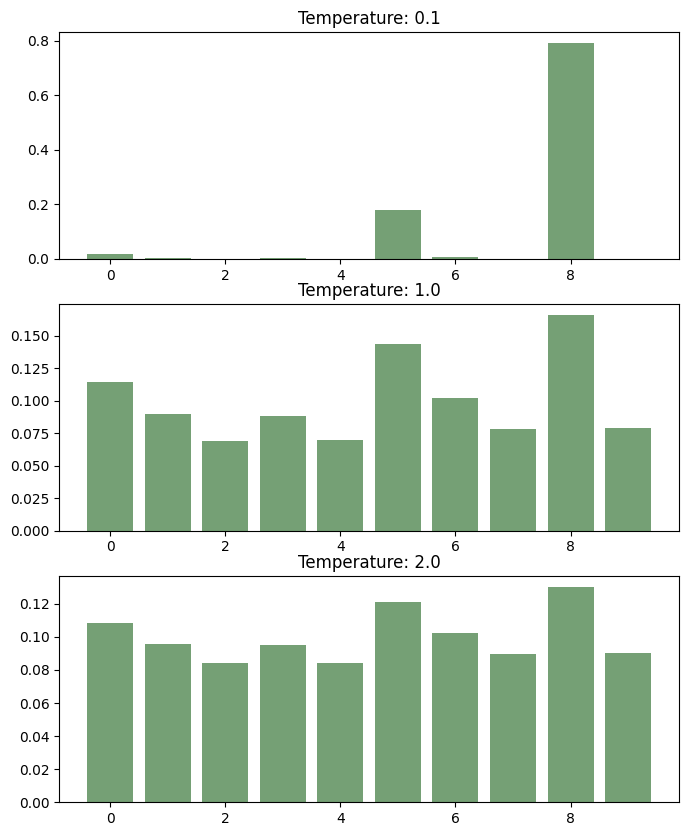

In [50]:
import matplotlib.pyplot as plt

GREEN = "#75a075"
temperature = [0.1, 1.0, 2.0]
fig, axes = plt.subplots(len(temperature), 1, figsize=(8, 10))
score = np.random.rand(10)
bins = np.arange(len(score))
for t, ax in zip(temperature, axes):
    prob = softmax(score, t)
    # 確率のヒストグラムを描画
    ax.bar(bins, prob, color=GREEN)
    ax.set_title(f"Temperature: {t}")

fig.savefig("softmax_temperature.png", dpi=300, bbox_inches="tight")

温度パラメータを用いた推論

In [ ]:
@torch.inference_mode
def temperature_inference(
    model: nn.Module,
    src: Tensor,
    bos_token: int,
    eos_token: int,
    temperature: float = 1.0,
    max_length: int = 50,
):
    tgt_tokens = torch.tensor([[bos_token]]).to(src.device)

    encoder_output = model.encoder(src)
    for _ in range(max_length):
        decoder_output = model.decoder(tgt_tokens, encoder_output)
        # 埋め込みベクトルを線形層に通して語彙数次元の確率分布(logits)を取得する線形層
        score = model.linear(decoder_output)

        # Softmax関数を温度パラメータで調整して確率分布を取得する
        #   温度パラメータによる変換
        score = score / temperature
        # 最後のトークンのスコアをSoftmax関数に通して確率分布を取得する
        porbability = F.softmax(score[0, -1], dim=-1)
        
        # トークンをサンプリング
        # 確率分布の確率に従って次のトークンを取得してpredに格納する
        pred = torch.multinomial(porbability, 1).unsqueeze(0) 
        tgt_tokens = torch.cat((tgt_tokens, pred), axis=-1)
        if pred[0, 0].item() == eos_token:
            break

    return tgt_tokens.squeeze()

In [67]:
text = "<bos> 今日 の 天気 は 晴れ です 。 <eos>"
tokens = text.split()
input_tokens = tokens_to_tensor([tokens], vocab_ja, vocab_ja["<pad>"]).to(device)
tgt_tokens = temperature_inference(
    model, input_tokens, vocab_en["<bos>"], vocab_en["<eos>"], max_length=20
)
itos = vocab_en.get_itos()
text = " ".join(itos[token_id] for token_id in tgt_tokens)
print(text)  # <bos> the weather is fine today . <eos>

<bos> the weather walked today 's do you put off . <eos>


(参考)サンプリングの検証  
Softmaxで取得した確立分布を`multinomial`に通すことで、確率分布の確率に従ってトークンIDをサンプリングする。

In [116]:
temperature=1.0
x = torch.tensor([1.3, 1.1, 1.4])
x = x / temperature
x = torch.exp(x)
porbability = torch.softmax(x, dim=-1)
print("porbability(temperature=1.0):", porbability)

# 確率分布に従ってランダムに次のトークンを取得してpredに格納する
pred = torch.multinomial(porbability, 1).unsqueeze(0) 
print("pred:", pred)


porbability(temperature=1.0): tensor([0.3350, 0.1723, 0.4928])
pred: tensor([[2]])


top-k サンプリング

In [ ]:
@torch.inference_mode
def top_k_inference(
    model: nn.Module,
    src: Tensor,
    bos_token: int,
    eos_token: int,
    temperature: float = 1.0,
    k: float = 5,
    max_length: int = 50,
):
    tgt_tokens = torch.tensor([[bos_token]]).to(src.device)

    encoder_output = model.encoder(src)
    for _ in range(max_length):
        decoder_output = model.decoder(tgt_tokens, encoder_output)
        score = model.linear(decoder_output)
        # 温度パラメータによる変換
        score = score / temperature
        probability = F.softmax(score[0, -1], dim=-1)

        # 確率の高い順にソートしたインデックスを取得
        idx_sorted = torch.argsort(probability, descending=True)
        # 上位k個のインデックスを取得
        idx_k = idx_sorted[:k]
        # 上位k個の確率を取得
        p_k = probability[idx_k]
        # 正規化
        p_k /= torch.sum(p_k)
        # トークンをサンプリング
        pred = torch.multinomial(p_k, 1)
        pred = idx_k[pred].unsqueeze(0)
        tgt_tokens = torch.cat((tgt_tokens, pred), axis=-1)
        if pred[0, 0].item() == eos_token:
            break

    return tgt_tokens.squeeze()

In [ ]:
text = "<bos> 今日 の 天気 は 晴れ です 。 <eos>"
tokens = text.split()
input_tokens = tokens_to_tensor([tokens], vocab_ja, vocab_ja["<pad>"]).to(device)
tgt_tokens = top_k_inference(
    model, input_tokens, vocab_en["<bos>"], vocab_en["<eos>"], max_length=20
)
itos = vocab_en.get_itos()
text = " ".join(itos[token_id] for token_id in tgt_tokens)
print(text)  # <bos> the weather is fine today . <eos>

top-p サンプリング

In [ ]:
@torch.inference_mode
def top_p_inference(
    model: nn.Module,
    src: Tensor,
    bos_token: int,
    eos_token: int,
    temperature: float = 1.0,
    p: float = 0.8,
    max_length: int = 50,
):
    tgt_tokens = torch.tensor([[bos_token]]).to(src.device)

    encoder_output = model.encoder(src)
    for _ in range(max_length):
        decoder_output = model.decoder(tgt_tokens, encoder_output)
        score = model.linear(decoder_output)
        # 温度パラメータによる変換
        score = score / temperature
        porbability = F.softmax(score[0, -1], dim=-1)
        idx_sorted = torch.argsort(porbability, descending=True)
        p_sorted = porbability[idx_sorted]
        # ソートされた確率の累積和を計算
        p_cumsum = torch.cumsum(p_sorted, dim=-1)
        # p を超える最初のインデックスを取得
        idx = torch.sum(p_cumsum < p).item() + 1
        # インデックスが範囲内に収まるように調整
        idx = min(idx, len(p_cumsum) - 1)
        # p を超えない範囲で上位の確率分布を取得
        p_top = p_sorted[:idx]
        # 正規化
        p_top = p_top / torch.sum(p_top)
        # トークンをサンプリング
        pred = torch.multinomial(p_top, 1).unsqueeze(0)
        pred = idx_sorted[pred]
        tgt_tokens = torch.cat((tgt_tokens, pred), axis=-1)
        if pred[0, 0].item() == eos_token:
            break

    return tgt_tokens.squeeze()

In [ ]:
text = "<bos> 今日 の 天気 は 晴れ です 。 <eos>"
tokens = text.split()
input_tokens = tokens_to_tensor([tokens], vocab_ja, vocab_ja["<pad>"]).to(device)
tgt_tokens = top_p_inference(
    model, input_tokens, vocab_en["<bos>"], vocab_en["<eos>"], max_length=20
)
itos = vocab_en.get_itos()
text = " ".join(itos[token_id] for token_id in tgt_tokens)
print(text)  # <bos> the weather is fine today . <eos>